# 📈 Notebook 1 — Buy-Write (Covered Call)
> SPY Weekly ATM Covered Call  |  7 DTE  |  Δ≈0.50  |  Mid execution

---

## 1. Theory

The **buy-write** sells a call against a long equity position, capturing the **variance risk premium** (IV > realized vol) while reducing effective delta.

$$\text{P\&L} = (S_T - S_0) + c - \max(S_T - K, 0)$$

**Greeks:** Δ≈+0.50, Γ<0, Θ>0, ν<0 — short volatility, long theta.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import load_data
from src.plotting    import *
from src.metrics     import compute_metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

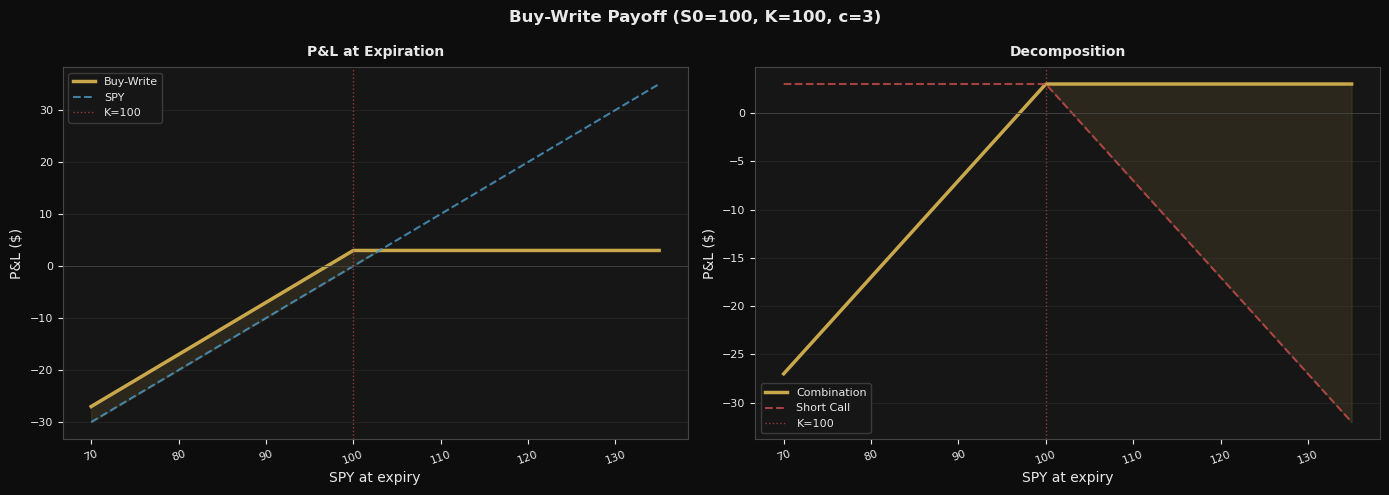

In [2]:
# Payoff diagram
fig, axes = plt.subplots(1,2,figsize=(14,5),facecolor=BG)
S0,K,c = 100,100,3
ST = np.linspace(70,135,400)
pnl_spy = ST-S0; pnl_bw = pnl_spy+c-np.maximum(ST-K,0)
for ax,title,y1,y2,col1,col2,lab1,lab2 in [
    (axes[0],'P&L at Expiration',pnl_bw,pnl_spy,GOLD,BLUE,'Buy-Write','SPY'),
    (axes[1],'Decomposition',pnl_bw,c-np.maximum(ST-K,0),GOLD,RED,'Combination','Short Call')]:
    ax.plot(ST,y1,color=col1,lw=2.5,label=lab1)
    ax.plot(ST,y2,color=col2,lw=1.5,ls='--',label=lab2,alpha=0.8)
    ax.fill_between(ST,y1,y2,where=y1>=y2,alpha=0.12,color=col1)
    ax.axvline(K,color=RED,lw=1,ls=':',alpha=0.7,label=f'K={K}')
    style_ax(ax,title); legend(ax)
    ax.set_xlabel('SPY at expiry'); ax.set_ylabel('P&L ($)')
fig.suptitle('Buy-Write Payoff (S0=100, K=100, c=3)',color=WHITE,fontsize=12,fontweight='bold')
fig.patch.set_facecolor(BG); plt.tight_layout(); plt.show()

## 2. Strategy Construction

At each **roll date** (weekly expiration):
1. Select call with DTE≈7 and Δ≈0.50
2. Sell at mid price → `Cash += premium`
3. At expiration: `Cash -= max(S_T - K, 0)`

$$V_t = S_t + \text{Cash}_t - \text{Call}_{\text{MTM},t}$$

In [3]:
#DATA_PATH = '../data/spy_simulated_2020_2022.csv'
# Uncomment to use real data:
DATA_PATH = '../data/spy_2020_2022.csv'

df = load_data(DATA_PATH)
print('Data loaded:', df.shape)

✅  Loaded: ../data/spy_2020_2022.csv
    Rows            : 3,589,079
    Period          : 2020-01-02 → 2022-12-30
    Trading days    : 758
    Unique strikes  : 641
    Unique expiries : 514
Data loaded: (3589079, 35)


In [4]:
from src.strategy_buywrite import build_buywrite
bw = build_buywrite(df, target_dte=7, target_delta=0.50)
bw[['spy_price','index_level','spy_bnh','call_strike','call_premium','call_iv']].tail(10)

✅  Buy-Write index built
    Days      : 758
    Rolls     : 47
    Avg IV    : 20.09%
    Avg prem  : 3.727


,spy_price,index_level,spy_bnh,call_strike,call_premium,call_iv
date,,,,,,
2022-12-19,380.02,107.653831,116.976021,355.0,3.475,0.18012
2022-12-20,380.49,107.798504,117.120694,355.0,3.475,0.18012
2022-12-21,386.21,109.559208,118.881399,355.0,3.475,0.18012
2022-12-22,380.72,107.869302,117.191492,355.0,3.475,0.18012
2022-12-23,382.88,108.534183,117.856373,355.0,3.475,0.18012
2022-12-26,382.91,108.543417,117.865608,355.0,3.475,0.18012
2022-12-27,381.38,108.072460,117.394650,355.0,3.475,0.18012
2022-12-28,376.71,106.634962,115.957152,355.0,3.475,0.18012
2022-12-29,383.33,108.672700,117.994890,355.0,3.475,0.18012


## 3. Performance Dashboard

  Chart saved → ../outputs/chart_buywrite.png


/Users/kingced/Desktop/PersonalTraining/Options strat/Option Index Strat /spy_options_repo/src/plotting.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


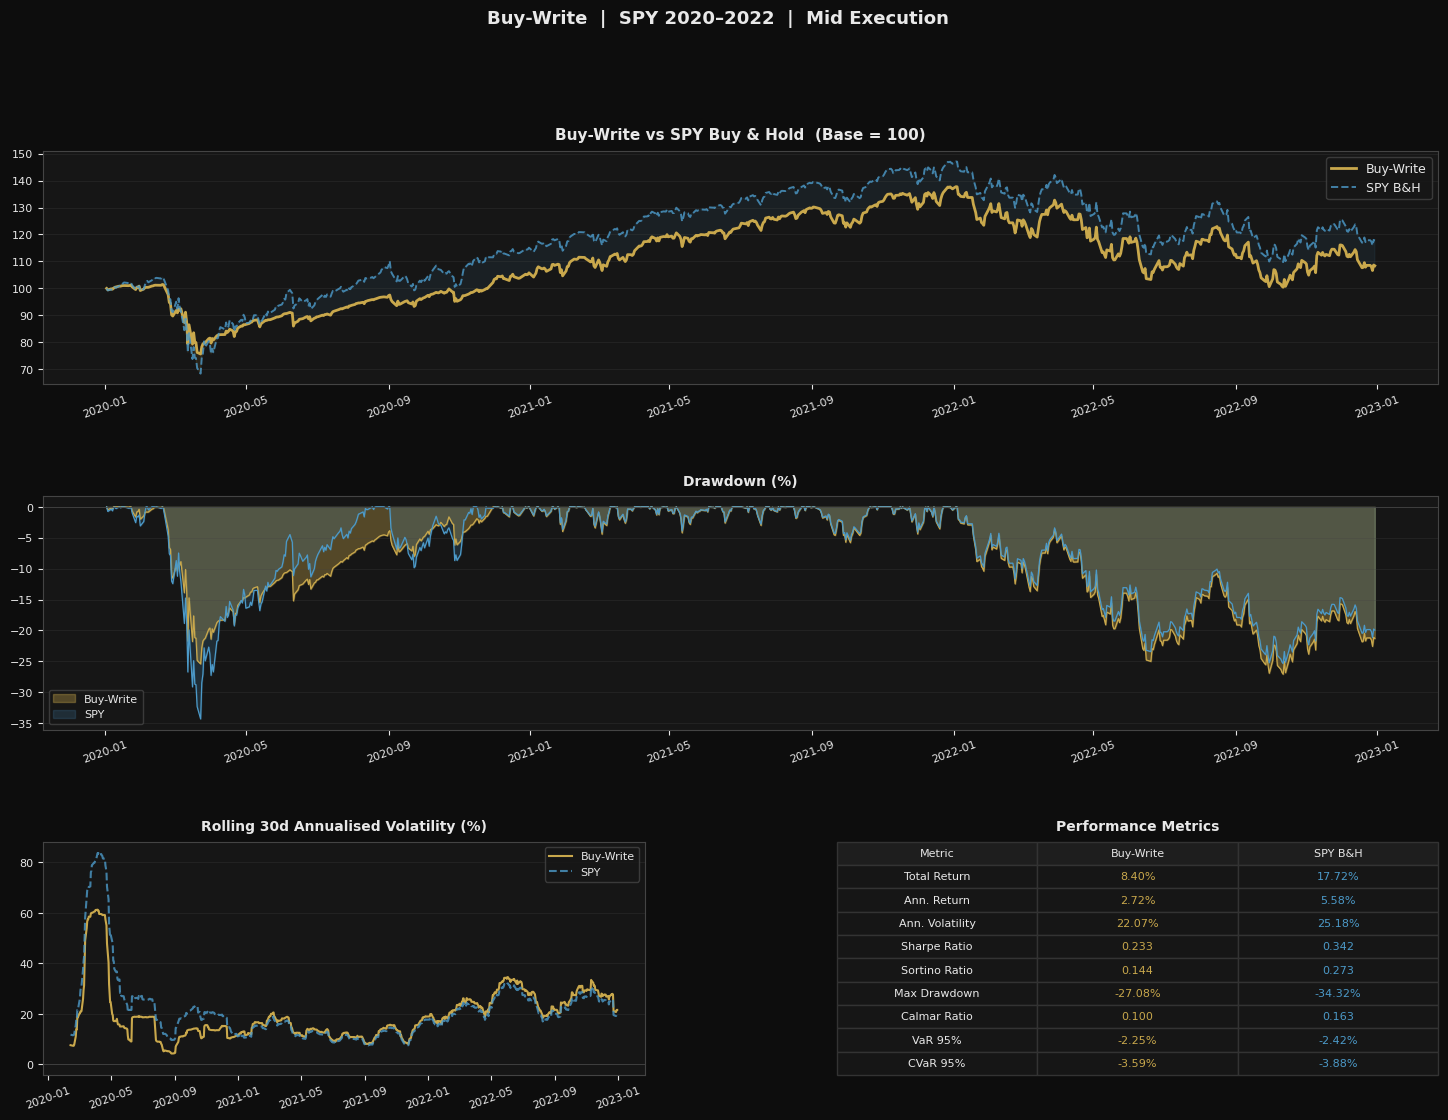

In [5]:
from src.plotting import plot_strategy_dashboard
plot_strategy_dashboard(bw, 'Buy-Write', GOLD,
                        save_path='../outputs/chart_buywrite.png')

## 4. Metrics

In [6]:
m = compute_metrics(bw)
for k,v in m.items():
    if isinstance(v,float): print(f'  {k:<25} {v:.4f}')

  Total Return              0.0840
  Ann. Return               0.0272
  Ann. Volatility           0.2207
  Skewness                  -0.6187
  Kurtosis                  7.7040
  Max Drawdown              -0.2708
  Avg DD Duration           15.1818
  Sharpe Ratio              0.2326
  Sortino Ratio             0.1443
  Calmar Ratio              0.1005
  Omega Ratio               1.0455
  VaR 95%                   -0.0225
  CVaR 95%                  -0.0359
